In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
df = pd.read_csv('/kaggle/input/bimaster-oficina-02-introducao-a-ia-sky/sky.csv')
df.head()

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,class,redshift,plate,mjd,id
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,STAR,-0.000009,3306,54922,1
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,STAR,-0.000055,323,51615,2
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,GALAXY,0.123111,287,52023,3
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,STAR,-0.000111,3306,54922,4
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,STAR,0.000590,3306,54922,5


In [3]:
df1 = pd.read_csv('/kaggle/input/bimaster-oficina-02-introducao-a-ia-sky/exemplo_submissao.csv')
df1.head()

,id,class
0,10001,GALAXY
1,10002,GALAXY
2,10003,GALAXY
3,10004,GALAXY
4,10005,GALAXY


In [4]:
combined = pd.concat([df,df1])
combined.head()

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,class,redshift,plate,mjd,id
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752.0,301.0,4.0,267.0,STAR,-0.000009,3306.0,54922.0,1
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752.0,301.0,4.0,267.0,STAR,-0.000055,323.0,51615.0,2
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752.0,301.0,4.0,268.0,GALAXY,0.123111,287.0,52023.0,3
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752.0,301.0,4.0,269.0,STAR,-0.000111,3306.0,54922.0,4
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752.0,301.0,4.0,269.0,STAR,0.000590,3306.0,54922.0,5


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10574 entries, 0 to 573
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   run       10000 non-null  float64
 8   rerun     10000 non-null  float64
 9   camcol    10000 non-null  float64
 10  field     10000 non-null  float64
 11  class     10574 non-null  object 
 12  redshift  10000 non-null  float64
 13  plate     10000 non-null  float64
 14  mjd       10000 non-null  float64
 15  id        10574 non-null  int64  
dtypes: float64(14), int64(1), object(1)
memory usage: 1.4+ MB


In [7]:
combined.dtypes

ra          float64
dec         float64
u           float64
g           float64
r           float64
i           float64
z           float64
run         float64
rerun       float64
camcol      float64
field       float64
class        object
redshift    float64
plate       float64
mjd         float64
id            int64
dtype: object

In [8]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
ra,10000.0,175.529987,47.783439,8.235100,157.370946,180.394514,201.547279,260.884382
dec,10000.0,14.836148,25.212207,-5.382632,-0.539035,0.404166,35.649397,68.542265
u,10000.0,18.619355,0.828656,12.988970,18.178035,18.853095,19.259232,19.599900
g,10000.0,17.371931,0.945457,12.799550,16.815100,17.495135,18.010145,19.918970
r,10000.0,16.840963,1.067764,12.431600,16.173333,16.858770,17.512675,24.802040
i,10000.0,16.583579,1.141805,11.947210,15.853705,16.554985,17.258550,28.179630
z,10000.0,16.422833,1.203188,11.610410,15.618285,16.389945,17.141447,22.833060
run,10000.0,981.034800,273.305024,308.000000,752.000000,756.000000,1331.000000,1412.000000
rerun,10000.0,301.000000,0.000000,301.000000,301.000000,301.000000,301.000000,301.000000
camcol,10000.0,3.648700,1.666183,1.000000,2.000000,4.000000,5.000000,6.000000


In [9]:
combined.columns

Index(['ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run', 'rerun', 'camcol', 'field',
       'class', 'redshift', 'plate', 'mjd', 'id'],
      dtype='object')

In [10]:
combined.shape

(10574, 16)

In [11]:
combined.isnull().sum()/len(combined*100)

ra          0.054284
dec         0.054284
u           0.054284
g           0.054284
r           0.054284
i           0.054284
z           0.054284
run         0.054284
rerun       0.054284
camcol      0.054284
field       0.054284
class       0.000000
redshift    0.054284
plate       0.054284
mjd         0.054284
id          0.000000
dtype: float64

In [12]:
combined.kurt

<bound method NDFrame._add_numeric_operations.<locals>.kurt of              ra       dec         u         g         r         i         z  \
0    183.531326  0.089693  19.47406  17.04240  15.94699  15.50342  15.22531   
1    183.598370  0.135285  18.66280  17.21449  16.67637  16.48922  16.39150   
2    183.680207  0.126185  19.38298  18.19169  17.47428  17.08732  16.80125   
3    183.870529  0.049911  17.76536  16.60272  16.16116  15.98233  15.90438   
4    183.883288  0.102557  17.55025  16.26342  16.43869  16.55492  16.61326   
..          ...       ...       ...       ...       ...       ...       ...   
569         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
570         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
571         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
572         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
573         NaN       NaN       NaN       NaN       NaN       NaN   

In [13]:
combined.skew

<bound method NDFrame._add_numeric_operations.<locals>.skew of              ra       dec         u         g         r         i         z  \
0    183.531326  0.089693  19.47406  17.04240  15.94699  15.50342  15.22531   
1    183.598370  0.135285  18.66280  17.21449  16.67637  16.48922  16.39150   
2    183.680207  0.126185  19.38298  18.19169  17.47428  17.08732  16.80125   
3    183.870529  0.049911  17.76536  16.60272  16.16116  15.98233  15.90438   
4    183.883288  0.102557  17.55025  16.26342  16.43869  16.55492  16.61326   
..          ...       ...       ...       ...       ...       ...       ...   
569         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
570         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
571         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
572         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
573         NaN       NaN       NaN       NaN       NaN       NaN   

<Axes: >

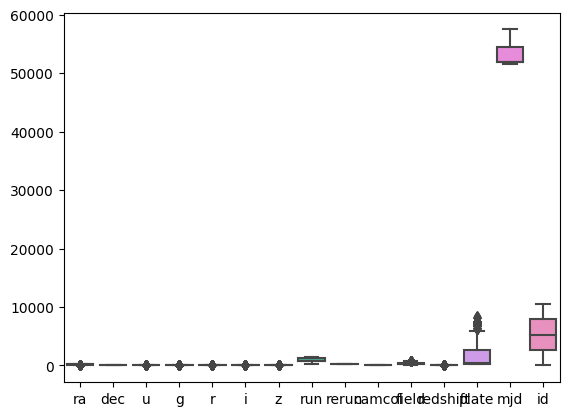

In [14]:
sns.boxplot(combined)

<Axes: >

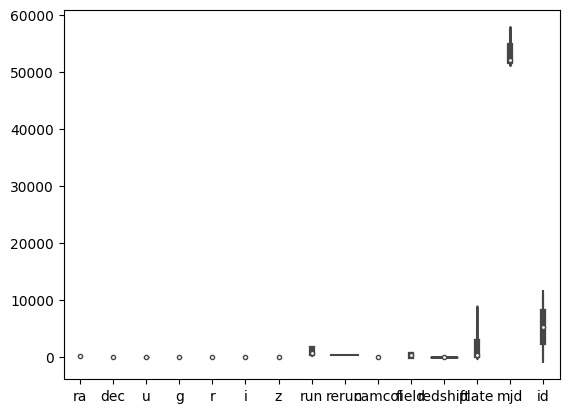

In [15]:
sns.violinplot(combined)

<Axes: >

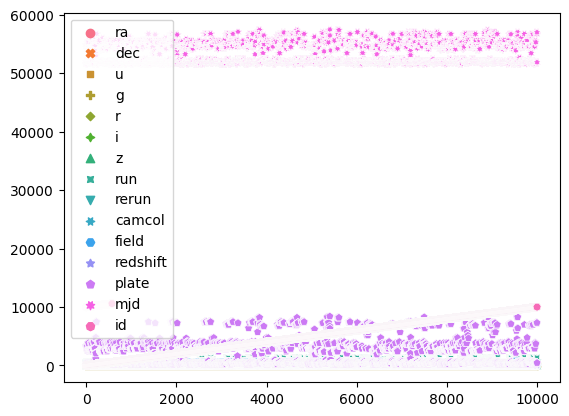

In [16]:
sns.scatterplot(combined)

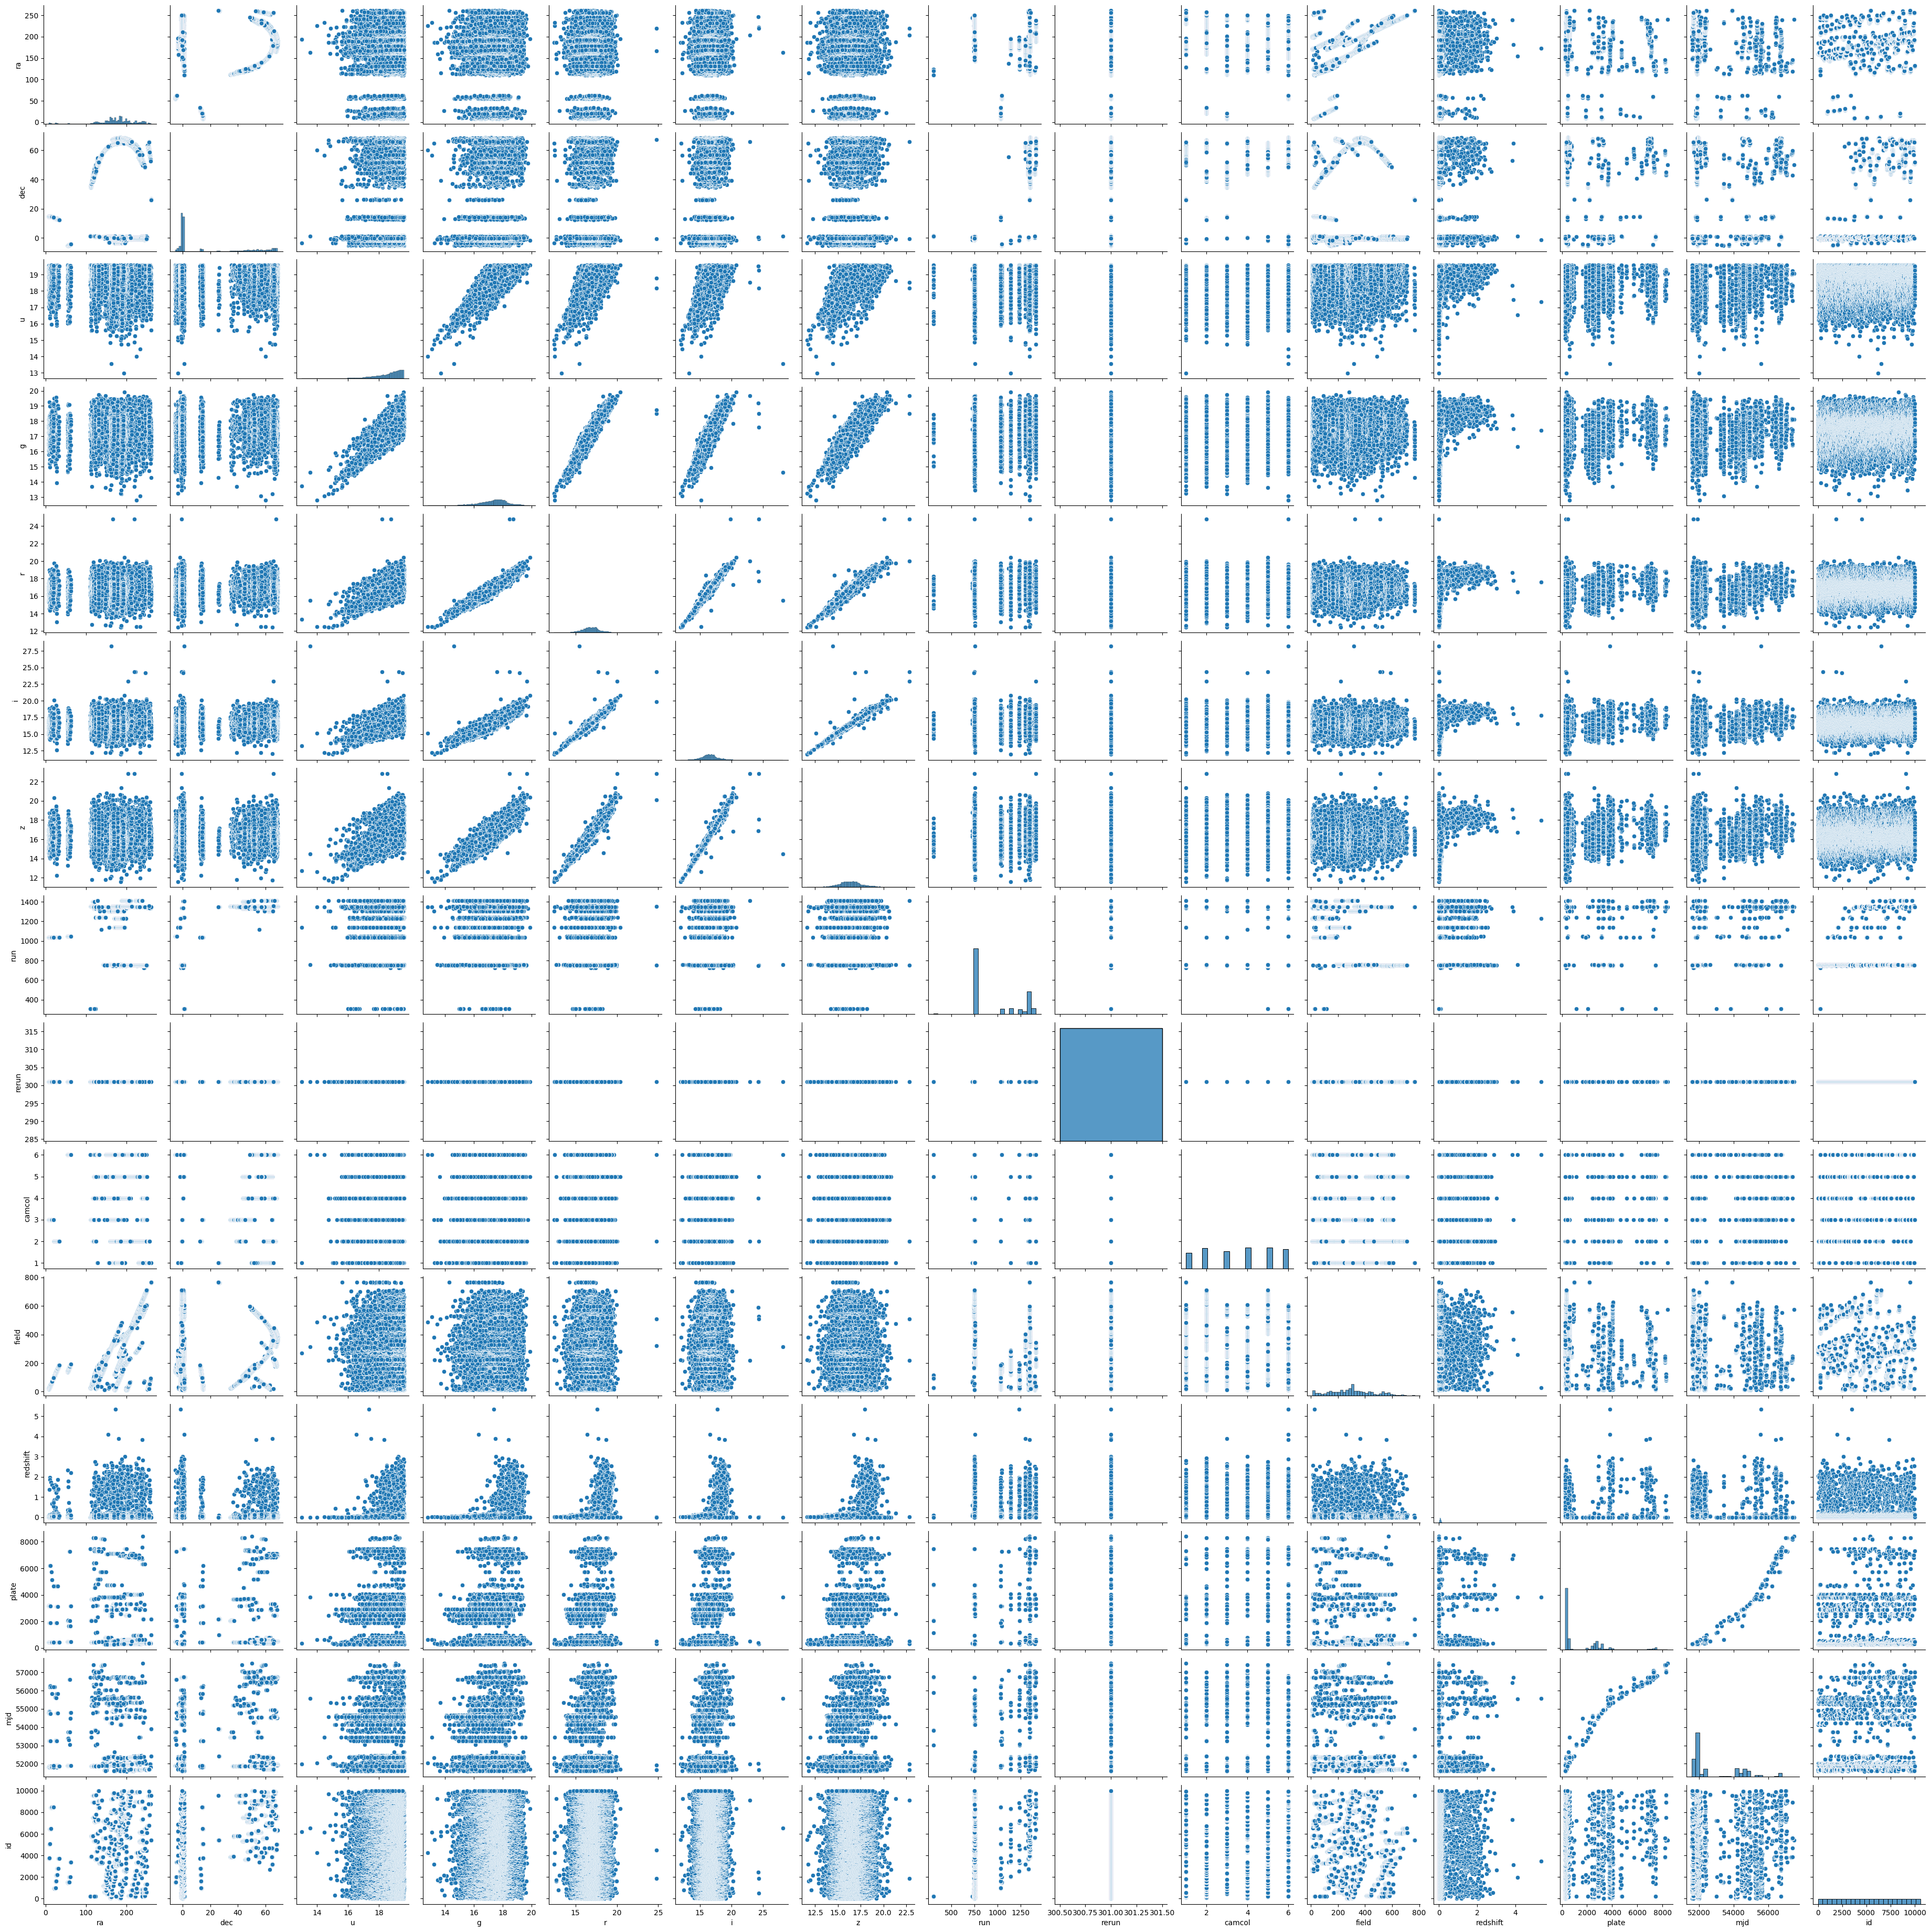

In [17]:
sns.pairplot(combined)

/tmp/ipykernel_47/3062371967.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(combined)


<Axes: ylabel='Density'>

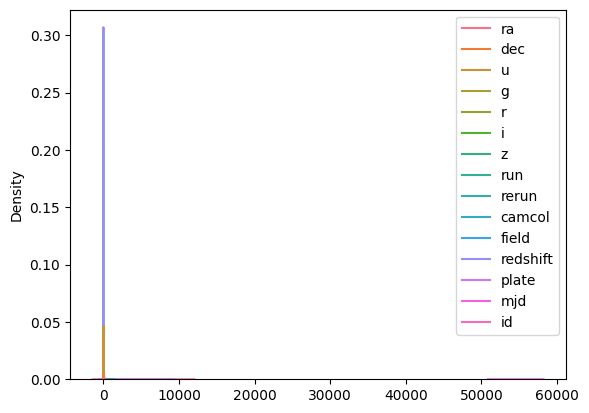

In [18]:
sns.kdeplot(combined)

In [5]:
cat_cols = combined.select_dtypes(include='object')

In [9]:
for i in cat_cols:
    (combined[i].value_counts())
    print(i)
    print(''*50)

class



In [7]:
num_cols = combined.select_dtypes(include='number')

In [8]:
for i in num_cols:
    (combined[i].value_counts())
    print(i)
    print(''*100)

ra

dec

u

g

r

i

z

run

rerun

camcol

field

redshift

plate

mjd

id



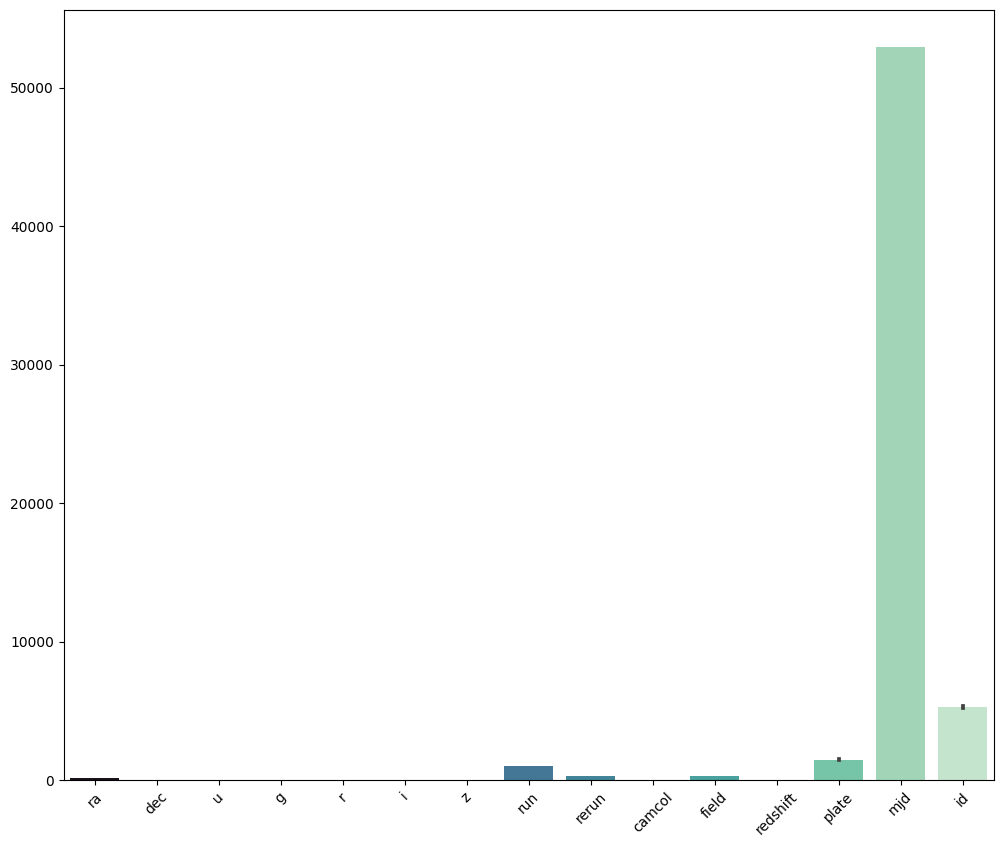

In [23]:
plt.figure(figsize=(12,10))
sns.barplot(combined,palette='mako');
plt.xticks(rotation=45);

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, 'ra'),
  Text(1, 0, 'dec'),
  Text(2, 0, 'u'),
  Text(3, 0, 'g'),
  Text(4, 0, 'r'),
  Text(5, 0, 'i'),
  Text(6, 0, 'z'),
  Text(7, 0, 'run'),
  Text(8, 0, 'rerun'),
  Text(9, 0, 'camcol'),
  Text(10, 0, 'field'),
  Text(11, 0, 'redshift'),
  Text(12, 0, 'plate'),
  Text(13, 0, 'mjd'),
  Text(14, 0, 'id')])

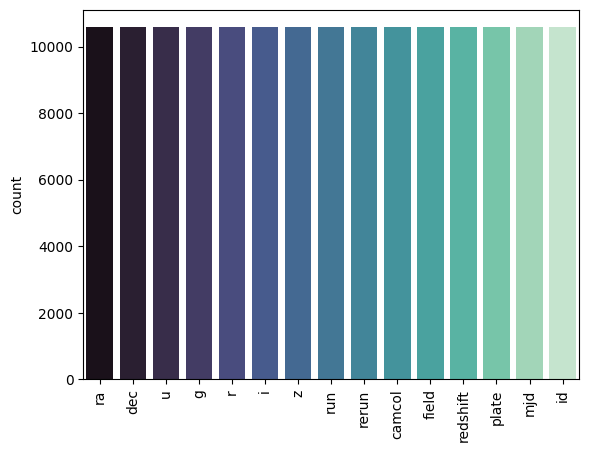

In [10]:
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=90)

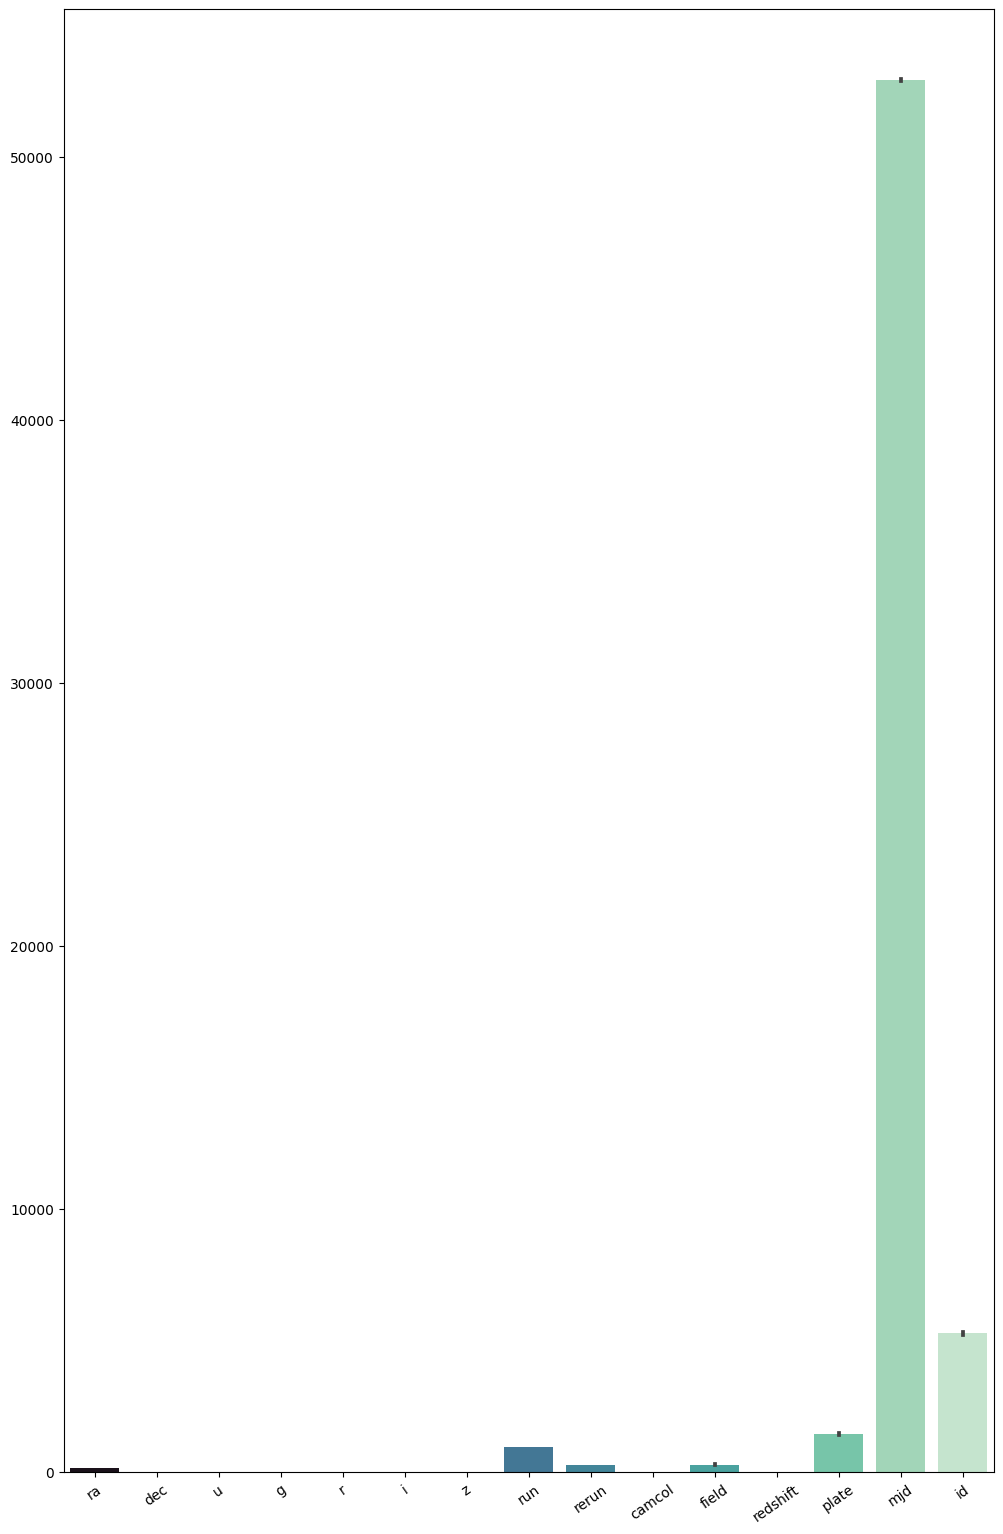

In [11]:
plt.figure(figsize=(12,19))
sns.barplot(combined,palette='mako');
plt.xticks(rotation=35);

<Axes: >

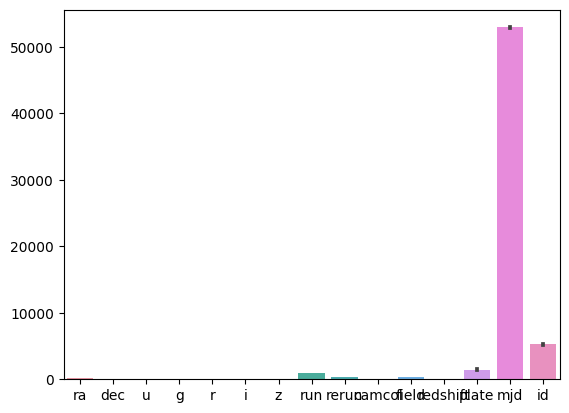

In [13]:
sns.barplot(combined)

<Axes: ylabel='count'>

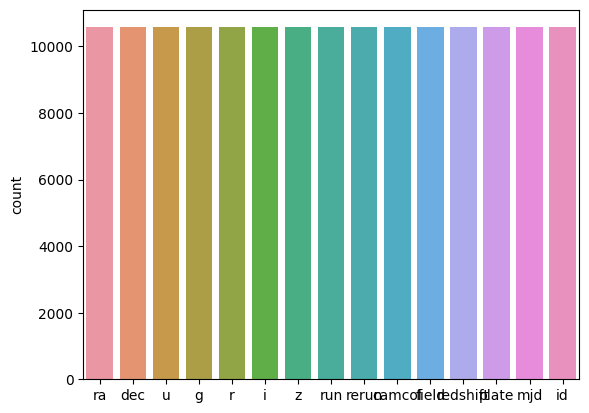

In [14]:
sns.countplot(combined)

<Axes: >

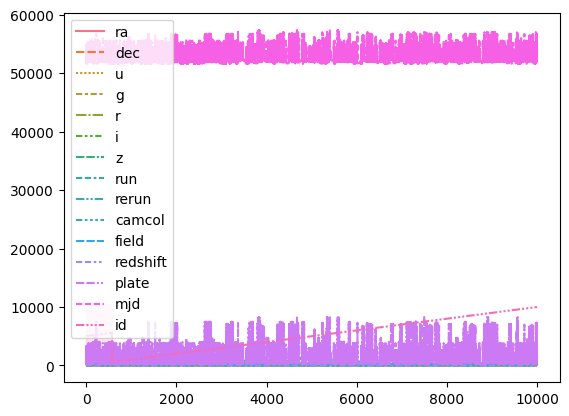

In [16]:
sns.lineplot(combined)

In [17]:
combined.head()

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,class,redshift,plate,mjd,id
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752.0,301.0,4.0,267.0,STAR,-0.000009,3306.0,54922.0,1
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752.0,301.0,4.0,267.0,STAR,-0.000055,323.0,51615.0,2
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752.0,301.0,4.0,268.0,GALAXY,0.123111,287.0,52023.0,3
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752.0,301.0,4.0,269.0,STAR,-0.000111,3306.0,54922.0,4
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752.0,301.0,4.0,269.0,STAR,0.000590,3306.0,54922.0,5


In [5]:
x = combined[['id']]

In [6]:
y = combined[['id']]

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(x_train,y_train)

LinearRegression()

In [12]:
y_pred =lr.predict(x_test)

In [13]:
y_test.head(),y_pred[0:5]

(        id
 1356  1357
 3252  3253
 3069  3070
 875    876
 7169  7170,
 array([[1357.],
        [3253.],
        [3070.],
        [ 876.],
        [7170.]]))

In [14]:
from sklearn.metrics import mean_squared_error

In [15]:
mean_squared_error (y_test,y_pred)

0.0

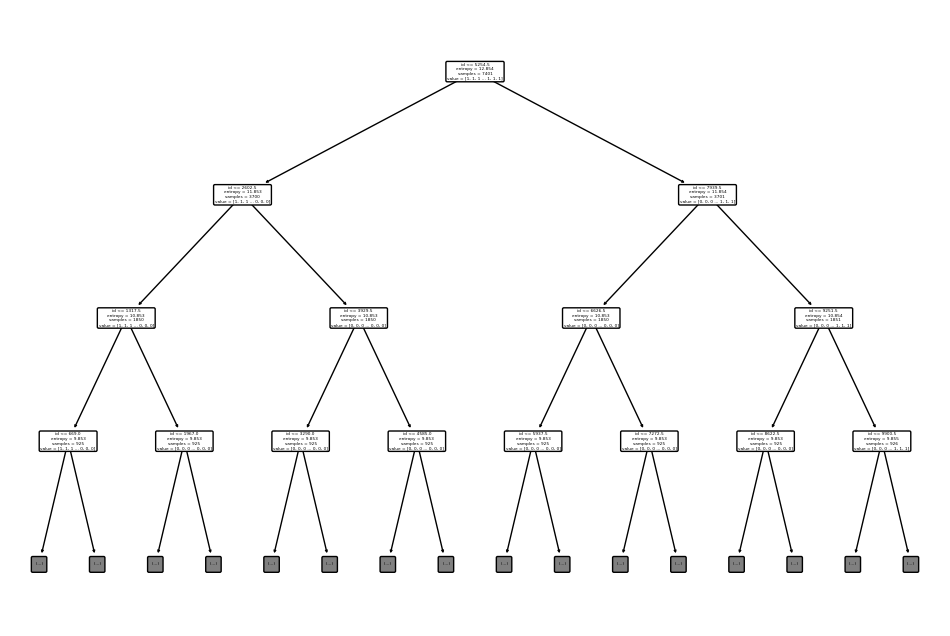

In [16]:
from sklearn.tree import DecisionTreeClassifier , plot_tree
import matplotlib.pyplot as plt

decision_tree_classification = DecisionTreeClassifier(criterion= 'entropy', random_state=10)
decision_tree = decision_tree_classification.fit(x_train,y_train)

plt.figure(figsize=(12,8))
plot_tree(decision_tree,max_depth=3, feature_names=x_train.columns, rounded=True)
plt.show()

In [17]:
y_pred_test = decision_tree.predict(x_test)
y_pred_train = decision_tree.predict(x_train)
print(decision_tree)

DecisionTreeClassifier(criterion='entropy', random_state=10)


In [18]:
from sklearn.metrics import classification_report
print(classification_report (y_train,y_pred_train))

              precision    recall  f1-score   support

           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          17       1.00      1.00      1.00         1
          18       1.00      1.00      1.00         1
          19       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         1
          22       1.00      1.00      1.00         1
          23       1.00      1.00      1.00         1
          25       1.00      1.00      1.00         1
          27       1.00    

In [42]:
print(len(y_train,),len(y_pred_train))

7401 7401


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

In [ ]:
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))